In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Install the kaggle CLI library
!pip install -q kaggle

import os
os.environ['KAGGLE_USERNAME'] = 'tanuja1838'
os.environ['KAGGLE_KEY'] = 'd236ad21574707dfd4039375b8a26a69'

# Download and unzip directly into the 'olist_data' directory
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset --unzip -p ./fake_news_data

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
100% 41.0M/41.0M [00:02<00:00, 15.3MB/s]



In [3]:
import os
import pandas as pd

# Path to the directory where your fake news data was unzipped
DATA_DIR = "./fake_news_data"

# Load the fake and true news datasets into DataFrames
fake_df = pd.read_csv(os.path.join(DATA_DIR, "Fake.csv"))
true_df = pd.read_csv(os.path.join(DATA_DIR, "True.csv"))

# Save them to your local environment or working directory
fake_df.to_csv("fake_news_saved.csv", index=False)
true_df.to_csv("true_news_saved.csv", index=False)


In [5]:
fake_df.sample(5)

,title,text,subject,date
8460,Bernie Sanders Hits Back At The Media In The ...,"On Wednesday, The Washington Post published a ...",News,"January 29, 2016"
18993,LIBERAL SNOWFLAKE Ambushes Sean Spicer in Appl...,Read more: Daily Mail,left-news,"Mar 13, 2017"
3705,Trump’s New York Times Meeting Ends In DISAST...,Donald Trump s Tuesday meeting with The New Yo...,News,"November 22, 2016"
22206,Boiler Room #97 – Mermaids and Swamp Life,Tune in to the Alternate Current Radio Network...,US_News,"February 17, 2017"
5938,Pro – Clinton PAC Launches New Website Chroni...,"Today, Donald Trump tried to walk back his rec...",News,"June 10, 2016"


In [6]:
true_df.sample(5)

,title,text,subject,date
3424,Quick debt limit move needed as tax receipts s...,WASHINGTON (Reuters) - The top Democrat in the...,politicsNews,"June 2, 2017"
8159,Blocking Internet oversight transition a 'gift...,WASHINGTON (Reuters) - Delaying or blocking a ...,politicsNews,"September 14, 2016"
4788,U.S. farm heartland lobbies to steer Trump awa...,"GARNER, Iowa/MEXICO CITY (Reuters) - Farmers i...",politicsNews,"March 22, 2017"
3342,U.S. Gulf Coast groups concerned as Trump pick...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"June 7, 2017"
11706,Swiss government urges voters to reject call f...,ZURICH (Reuters) - The Swiss government urged ...,worldnews,"December 20, 2017"


In [7]:
fake_df.shape

(23481, 4)

In [8]:
true_df.shape

(21417, 4)

In [9]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [10]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [11]:
fake_df.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [12]:
true_df.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [13]:
fake_df.duplicated().sum()

np.int64(3)

In [14]:
true_df.duplicated().sum()

np.int64(206)

In [18]:
true_df['subject'].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


<Axes: xlabel='subject'>

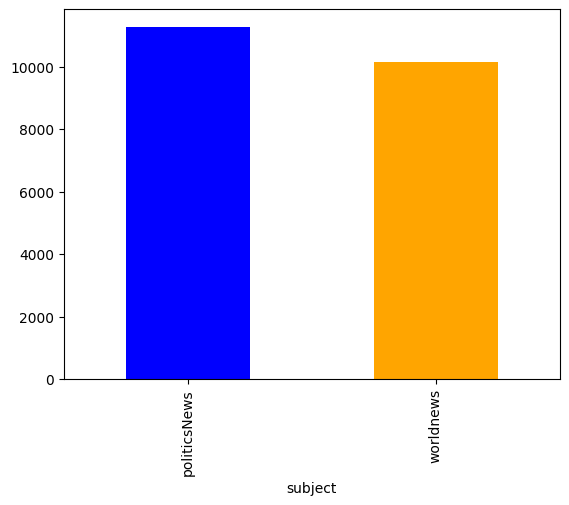

In [19]:
# Vertical bar chart
true_df['subject'].value_counts().plot(kind='bar', color=['blue', 'orange'])

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64


<Axes: xlabel='subject'>

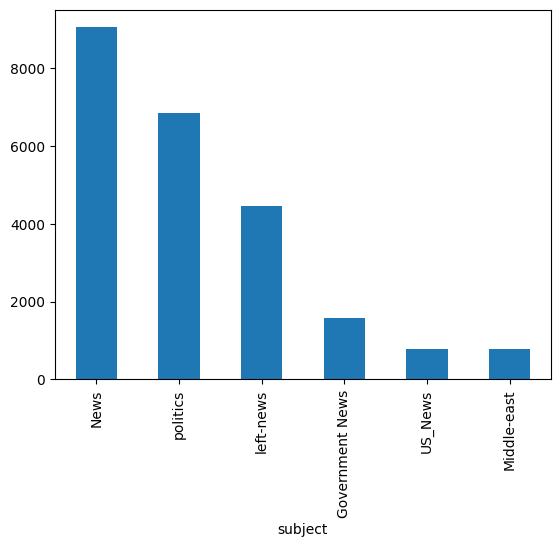

In [21]:
print(fake_df['subject'].value_counts())
fake_df['subject'].value_counts().plot(kind='bar')

In [24]:
fake_df["length"] = fake_df["text"].apply(len)
true_df["length"] = true_df["text"].apply(len)

In [25]:
fake_df

,title,text,subject,date,length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",2893
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1898
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",3597
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",2774
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",2346
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",3237
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",1684
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",25065
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",2685


In [26]:
true_df

,title,text,subject,date,length
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",4659
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",4077
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",2789
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",2461
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",5204
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",2821
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",800
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1950
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1199


In [28]:
fake_df['length'].describe()

,length
count,23481.000000
mean,2547.396235
std,2532.884399
min,1.000000
25%,1433.000000
50%,2166.000000
75%,3032.000000
max,51794.000000


In [29]:
true_df['length'].describe()

,length
count,21417.000000
mean,2383.278517
std,1684.835730
min,1.000000
25%,914.000000
50%,2222.000000
75%,3237.000000
max,29781.000000


In [30]:
fake_df["label"] = 0
true_df["label"] = 1

In [31]:
fake_df

,title,text,subject,date,length,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",2893,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1898,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",3597,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",2774,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",2346,0
...,...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",3237,0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",1684,0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",25065,0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",2685,0


In [32]:
df = pd.concat([fake_df, true_df], ignore_index=True)

In [33]:
df

,title,text,subject,date,length,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",2893,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1898,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",3597,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",2774,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",2346,0
...,...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",2821,1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",800,1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1950,1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1199,1


In [34]:
df.shape

(44898, 6)

In [35]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [36]:
df.sample(5)

,title,text,subject,date,length,label
37533,WATCH: Joy Reid Has PERFECT Response To Melan...,As conservatives rushed to find excuses for Me...,News,"July 19, 2016",3720,0
31604,Turkey issues warrants for 106 'matchmakers' i...,ISTANBUL (Reuters) - Turkish authorities issue...,worldnews,"December 18, 2017",1724,1
6190,CSU nominates right-winger as candidate for Ba...,MUNICH (Reuters) - Lawmakers of Germany s Chri...,worldnews,"December 4, 2017",693,1
20915,Trump's CIA pick supports domestic surveillanc...,WASHINGTON (Reuters) - Representative Mike Pom...,politicsNews,"November 18, 2016",5588,1
12805,New Poll Shows 40 Percent Of Trump Supporters...,When Hillary Clinton called out half of Trum...,News,"September 28, 2016",2075,0


In [37]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


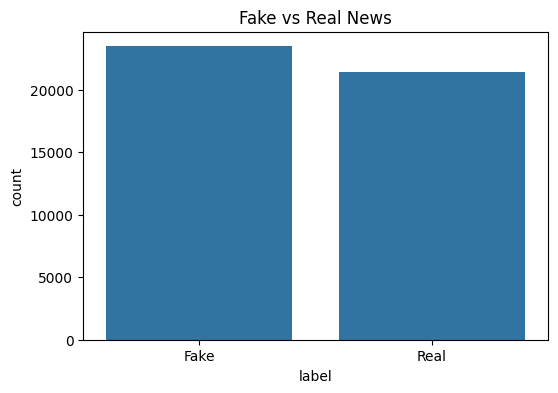

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label")

plt.title("Fake vs Real News")
plt.xticks([0,1],["Fake","Real"])

plt.show()

In [41]:
df.columns

Index(['title', 'text', 'subject', 'date', 'length', 'label'], dtype='object')

In [42]:
df = df.drop(columns=['length'])

In [43]:
df

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0


In [44]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [45]:
df["article_length"] = df["text"].apply(len)

In [46]:
df[["article_length", "label"]].head()

,article_length,label
0,1028,0
1,4820,1
2,1848,1
3,1244,0
4,3137,1


In [47]:
df.groupby("label")["article_length"].mean()

,article_length
label,
0,2547.396235
1,2383.278517


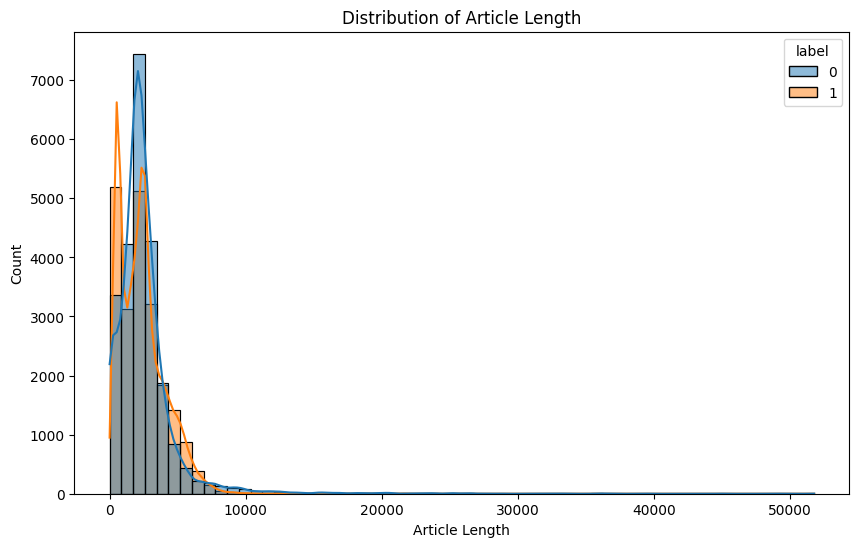

In [48]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="article_length",
    hue="label",
    bins=60,
    kde=True
)

plt.xlabel("Article Length")
plt.ylabel("Count")
plt.title("Distribution of Article Length")

plt.show()

In [49]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

In [50]:
df.groupby("label")["word_count"].mean()

,word_count
label,
0,423.197905
1,385.640099


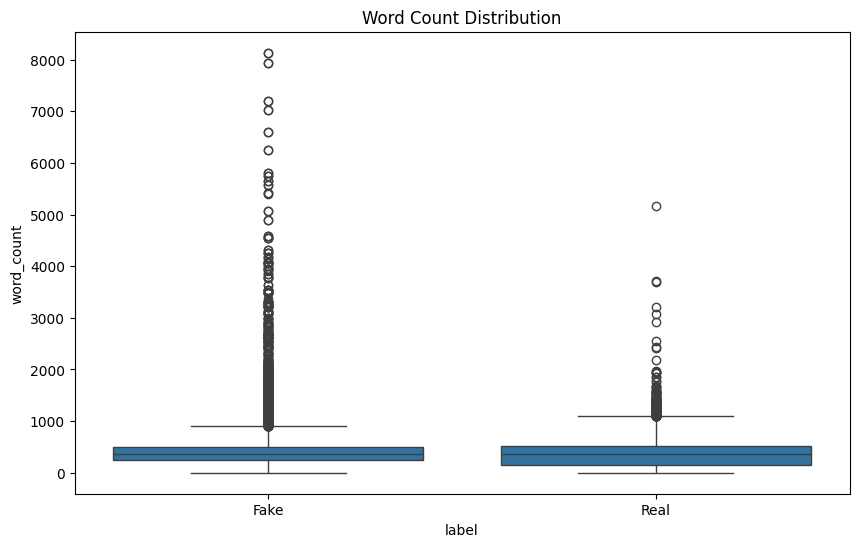

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.xticks([0,1],["Fake","Real"])

plt.title("Word Count Distribution")

plt.show()

Before training the model, I explored the dataset by comparing article lengths and word counts between fake and real news to understand whether basic textual characteristics differed.

# **Data Cleaning**

In [52]:
df["content"] = df["title"] + " " + df["text"]

In [53]:
df[["content"]].head()

,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...


In [54]:
df = df[["content", "label"]]

In [55]:
df.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [56]:
print(df["content"][0])

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Orde

# **NLP Preprocessing**

Lowercasing

In [57]:
text = df["content"][0]

text = text.lower()

print(text)

ben stein calls out 9th circuit court: committed a ‘coup d’état’ against the constitution 21st century wire says ben stein, reputable professor from, pepperdine university (also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off) made some provocative statements on judge jeanine pirro s show recently. while discussing the halt that was imposed on president trump s executive order on travel. stein referred to the judgement by the 9th circuit court in washington state as a  coup d tat against the executive branch and against the constitution.  stein went on to call the judges in seattle  political puppets  and the judiciary  political pawns. watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the executive orde

In [58]:
import re

Remove URLs

In [59]:
text = re.sub(r"http\S+|www\S+", "", text)

print(text)

ben stein calls out 9th circuit court: committed a ‘coup d’état’ against the constitution 21st century wire says ben stein, reputable professor from, pepperdine university (also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off) made some provocative statements on judge jeanine pirro s show recently. while discussing the halt that was imposed on president trump s executive order on travel. stein referred to the judgement by the 9th circuit court in washington state as a  coup d tat against the executive branch and against the constitution.  stein went on to call the judges in seattle  political puppets  and the judiciary  political pawns. watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the executive orde

Remove HTML Tags

In [60]:
text = re.sub(r"<.*?>", "", text)

print(text)

ben stein calls out 9th circuit court: committed a ‘coup d’état’ against the constitution 21st century wire says ben stein, reputable professor from, pepperdine university (also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off) made some provocative statements on judge jeanine pirro s show recently. while discussing the halt that was imposed on president trump s executive order on travel. stein referred to the judgement by the 9th circuit court in washington state as a  coup d tat against the executive branch and against the constitution.  stein went on to call the judges in seattle  political puppets  and the judiciary  political pawns. watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the executive orde

In [61]:
import string

Remove Punctuation

In [62]:
text = text.translate(str.maketrans("", "", string.punctuation))

print(text)

ben stein calls out 9th circuit court committed a ‘coup d’état’ against the constitution 21st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge jeanine pirro s show recently while discussing the halt that was imposed on president trump s executive order on travel stein referred to the judgement by the 9th circuit court in washington state as a  coup d tat against the executive branch and against the constitution  stein went on to call the judges in seattle  political puppets  and the judiciary  political pawns watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the executive orderread mor

Remove Numbers

9th  → th

21st → st

In [63]:
text = re.sub(r"\d+", "", text)

print(text[:500])

ben stein calls out th circuit court committed a ‘coup d’état’ against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge jeanine pirro s show recently while discussing the halt that was imposed on president trump s executive order on travel stein referred to the judgement by the th circuit court in washington state as 


Remove Extra Spaces

In [64]:
text = re.sub(r"\s+", " ", text).strip()

print(text[:500])

ben stein calls out th circuit court committed a ‘coup d’état’ against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge jeanine pirro s show recently while discussing the halt that was imposed on president trump s executive order on travel stein referred to the judgement by the th circuit court in washington state as 


Tokenization

In [67]:
import nltk

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [69]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

tokens = word_tokenize(text)

print(tokens[:30])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...


['ben', 'stein', 'calls', 'out', 'th', 'circuit', 'court', 'committed', 'a', '‘', 'coup', 'd', '’', 'état', '’', 'against', 'the', 'constitution', 'st', 'century', 'wire', 'says', 'ben', 'stein', 'reputable', 'professor', 'from', 'pepperdine', 'university', 'also']


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Remove Stopwords

In [70]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [71]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

tokens = [word for word in tokens if word not in stop_words]

In [72]:
print(tokens[:30])

['ben', 'stein', 'calls', 'th', 'circuit', 'court', 'committed', '‘', 'coup', '’', 'état', '’', 'constitution', 'st', 'century', 'wire', 'says', 'ben', 'stein', 'reputable', 'professor', 'pepperdine', 'university', 'also', 'hollywood', 'fame', 'appearing', 'tv', 'shows', 'films']


Lemmatization

Instead of stemming, we'll use lemmatization, because it produces actual dictionary words.

In [73]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [74]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [75]:
tokens = [lemmatizer.lemmatize(word) for word in tokens]

Join Back Into Text

In [77]:
clean_text = " ".join(tokens)

print(clean_text[:500])

ben stein call th circuit court committed ‘ coup ’ état ’ constitution st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn w


In [78]:
print(clean_text[:500])

ben stein call th circuit court committed ‘ coup ’ état ’ constitution st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn w


In [79]:
text = re.sub(r"\b\w*\d\w*\b", "", text)

Defining function

In [80]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove html
    text = re.sub(r"<.*?>", "", text)

    # remove words containing numbers
    text = re.sub(r"\b\w*\d\w*\b", "", text)

    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords and non-alphabetic tokens
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [81]:
preprocess_text(df["content"][0])

'ben stein call circuit court committed coup état constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn watch interview complete statement note stark contrast rhetoric leftist medium pundit neglect note court ever blocked presidential order immigration past discus legal efficacy halt actual text executive orderread trump news century wire trump filessupport work subscribing becoming member tv'

In [82]:
df["clean_text"] = df["content"].apply(preprocess_text)

/tmp/ipykernel_1622/3421556082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["clean_text"] = df["content"].apply(preprocess_text)


In [84]:
df.to_csv("clean_fake_news.csv", index=False)

In [85]:
df.head()

,content,label,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0,ben stein call circuit court committed coup ét...
1,Trump drops Steve Bannon from National Securit...,1,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,1,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,0,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,1,donald trump head scotland reopen golf resort ...


# **Feature Engineering**

So we need to convert text into numbers.

This process is called Vectorization.

Separate Features and Target

In [86]:
X = df["clean_text"]

y = df["label"]

In [87]:
print(X.shape)
print(y.shape)

(44898,)
(44898,)


Train-Test Split

Why stratify=y?

It keeps the class proportions the same in both train and test sets.

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
print(X_train.shape)
print(X_test.shape)

(35918,)
(8980,)


TF-IDF Vectorization

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [91]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7
)

max_features=5000 → Keep the 5,000 most informative terms.

ngram_range=(1,2) → Use both single words (unigrams) and two-word phrases (bigrams).

 For example:
"trump"
"white house"

min_df=5 → Ignore words that appear in fewer than 5 documents (often typos or very rare words).

max_df=0.7 → Ignore words that appear in more than 70% of documents (they're usually too common to be useful).

In [92]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [93]:
print(X_train.shape)
print(X_test.shape)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(35918,)
(8980,)
(35918, 5000)
(8980, 5000)


# **Train the First Model (Logistic Regression)**

In [94]:
from sklearn.linear_model import LogisticRegression

In [95]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [96]:
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [97]:
y_pred = lr.predict(X_test_tfidf)

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [99]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9876
Precision: 0.9838
Recall   : 0.9904
F1 Score : 0.9871


In [100]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [101]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4626   70]
 [  41 4243]]


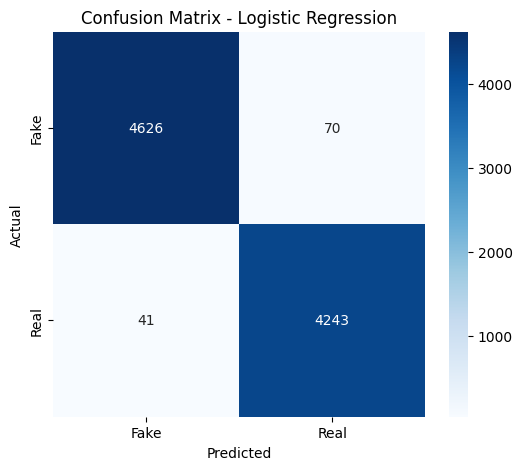

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

Although the model achieved around 99% accuracy on the dataset, I recognize that this dataset has inherent biases such as different news sources and subject distributions. Therefore, real-world performance may be lower.

In [103]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PassiveAggressiveClassifier

In [104]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Passive Aggressive": PassiveAggressiveClassifier(
        max_iter=1000,
        random_state=42
    )
}

In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    pred = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

In [106]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.997773,0.996507,0.998833,0.997668
2,Linear SVM,0.994766,0.993708,0.995331,0.994519
4,Passive Aggressive,0.994321,0.994394,0.993697,0.994046
0,Logistic Regression,0.987639,0.983770,0.990430,0.987089
1,Multinomial NB,0.942984,0.941066,0.939309,0.940187


In [107]:
results_df = results_df.round(4)
results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.9978,0.9965,0.9988,0.9977
2,Linear SVM,0.9948,0.9937,0.9953,0.9945
4,Passive Aggressive,0.9943,0.9944,0.9937,0.9940
0,Logistic Regression,0.9876,0.9838,0.9904,0.9871
1,Multinomial NB,0.9430,0.9411,0.9393,0.9402


Why did Random Forest outperform Linear SVM? Usually SVM is one of the best models for TF-IDF text classification.

In [108]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr.coef_[0]

Top words indicating Real News

In [109]:
top_real = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
}).sort_values(
    by="Coefficient",
    ascending=False
).head(20)

top_real

,Word,Coefficient
3719,reuters,24.579329
4849,washington reuters,9.793551
3321,president donald,5.500542
4867,wednesday,5.436101
4648,tuesday,5.127331
4846,washington,4.681245
4488,thursday,4.661113
3843,said statement,4.426095
1770,friday,4.334994
3720,reuters president,4.289668


Top words indicating Fake News

In [110]:
top_fake = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
}).sort_values(
    by="Coefficient",
    ascending=True
).head(20)

top_fake

,Word,Coefficient
4778,video,-9.218172
4768,via,-8.879036
2109,image,-8.302616
1859,gop,-5.904941
3328,president trump,-5.860624
2008,hillary,-5.694922
2110,image via,-4.963742
1478,even,-4.602393
3216,pictwittercom,-4.360883
2976,obama,-4.202996


Logistic Regression gives a clear coefficient for each TF-IDF feature, making it easy to interpret which words push predictions toward "fake" or "real".

Random Forest feature importance tells you which features matter, but it doesn't indicate which class a feature supports.

**Linear SVM is the industry standard for sparse TF-IDF text classification.**

In [113]:
import joblib

In [114]:
best_model = models["Linear SVM"]

In [116]:
joblib.dump(best_model, "fake_news_model.pkl")

['fake_news_model.pkl']

In [117]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [119]:
model = joblib.load("fake_news_model.pkl")

vectorizer = joblib.load("tfidf_vectorizer.pkl")

Build Prediction Function

In [120]:
def predict_news(news):

    clean = preprocess_text(news)

    vector = vectorizer.transform([clean])

    prediction = model.predict(vector)[0]

    if prediction == 0:
        return "Fake News"

    return "Real News"

In [121]:
predict_news("""
Donald Trump wins election after historic campaign.
""")

'Fake News'

In [122]:
predict_news("""
Aliens have landed in New York and NASA confirms
the Earth will end tomorrow.
""")

'Fake News'

In [124]:
news_text = """
Aliens have landed in New York and NASA confirms
the Earth will end tomorrow.
"""
clean = preprocess_text(news_text)
vector = vectorizer.transform([clean])
score = model.decision_function(vector)

print(score)

[-0.68874623]


Positive values lean toward one class, negative toward the other, and larger magnitudes indicate stronger confidence.